# local_poly_cv

> 对应代码：`EconometricsCode/code_in_notes/Chap.3/local_poly_cv.do`（本 notebook 中的 Stata 代码与 do 文件一致）
>
> 运行方式：通过 *PyStata* 在 Jupyter 中调用 Stata，安装与使用说明见 `notebooks/PyStata.md`。

**说明**：为在 notebook 中直接内联显示图形，本 notebook 的 Stata 代码省略了 `.do` 文件中的 `graph export` 导出命令（`code_in_notes` 中对应的 .do 文件保留导出，用于生成书中的插图）。

首先启动 Stata 环境，并把工作目录切换到 `code_in_notes/Chap.3`，这样 Stata 中的相对路径（如 `../datasets/...`）与同名 do 文件完全一致，图片也会输出到该目录。

In [1]:
# 配置 PyStata：启动 Stata 并注册 %%stata 魔法命令
import os
os.chdir("../../code_in_notes/Chap.3")

import stata_setup
stata_setup.config("/opt/Stata", "mp")


  ___  ____  ____  ____  ____ ®
 /__    /   ____/   /   ____/      Stata 18.0
___/   /   /___/   /   /___/       MP—Parallel Edition

 Statistics and Data Science       Copyright 1985-2023 StataCorp LLC
                                   StataCorp
                                   4905 Lakeway Drive
                                   College Station, Texas 77845 USA
                                   800-782-8272        https://www.stata.com
                                   979-696-4600        service@stata.com

Stata license: Single-user 16-core  perpetual
Serial number: 501806307019
  Licensed to: Keep calm and DO your research
               Jichun Si

Notes:
      1. Unicode is supported; see help unicode_advice.
      2. More than 2 billion observations are allowed; see help obs_advice.
      3. Maximum number of variables is set to 5,000 but can be increased;
          see help set_maxvar.


清理环境并设置随机种子，保证结果可复现。

In [2]:
%%stata
clear
set more off
// 生成数据
set seed 19880505


. clear

. set more off

. // 生成数据
. set seed 19880505

. 


我们生成与 local_constant.do 相同的数据：x 服从 [0,2] 均匀分布，y=exp(sin(x^3))+ε。这里额外保存真实函数值 y_true 并加上中文标签，用于后面画图时与估计结果对比。

In [3]:
%%stata
set obs 300
gen x=2*runiform()
gen y=exp(sin(x^3))+rnormal()
gen y_true=exp(sin(x^3))
label variable y_true "真实函数"


. set obs 300
Number of observations (_N) was 0, now 300.

. gen x=2*runiform()

. gen y=exp(sin(x^3))+rnormal()

. gen y_true=exp(sin(x^3))

. label variable y_true "真实函数"

. 


局部多项式回归需要以目标点 x=2 为中心构造多项式基。我们先生成一阶项 x_21=x-2，再用 forvalues 循环生成 2 至 5 阶的幂次项 (x-2)^p，供不同阶数 p 的局部多项式选用。

In [4]:
%%stata
// 生成高阶项
gen x_21=x-2
forvalues i=2/5{
    gen x_2`i'=x_21^`i'
}


. // 生成高阶项
. gen x_21=x-2

. forvalues i=2/5{
  2.     gen x_2`i'=x_21^`i'
  3. }

. 


为做交叉验证，我们选取离目标点 x=2 最近的 10 个观测作为测试集：先计算每个观测到 2 的绝对距离，按距离排序后，用 _n<=10 标记出最近的 10 个观测。

In [5]:
%%stata
// 标记测试集并记录测试集数量，选最近的10个作为测试集
gen absolute_distance=abs(x_21)
sort absolute_distance
gen test_set=_n<=10


. // 标记测试集并记录测试集数量，选最近的10个作为测试集
. gen absolute_distance=abs(x_21)

. sort absolute_distance

. gen test_set=_n<=10

. 


初始化交叉验证所需的控制变量：control 用来累积多项式项（每提高一阶 p 就往回归里加一项），argmin_p、argmin_h 记录当前最优的阶数与带宽，min_mse 记录当前最小的均方误差，先设成一个很大的数。

In [6]:
%%stata
// 初始化控制变量，每次增加p的时候自动添加
local control ""
// 初始化最优的p,h，并将min_mse设置为一个比较大的数
local argmin_p=0
local argmin_h=0
local min_mse=1e5


. // 初始化控制变量，每次增加p的时候自动添加
. local control ""

. // 初始化最优的p,h，并将min_mse设置为一个比较大的数
. local argmin_p=0

. local argmin_h=0

. local min_mse=1e5

. 


下面开始网格搜索：外层对多项式阶数 p=1,...,5 循环，每提高一阶就把对应的高阶项加入控制变量 local control，实现从局部线性到局部五阶的嵌套回归设定。

内层对带宽 h 从 0.01 到 0.5 以 0.01 为步长循环。对每组 (p,h)，先把交叉验证误差清零，再用正态核 normalden((x-2)/h) 生成权重：h 越小，权重越集中在 x=2 附近，估计越局部化、方差越大；h 越大则相反。

对选出的 10 个测试点做留一法交叉验证：每次用除第 i 个测试点之外的所有观测做加权局部多项式回归（_n~=`i' 表示排除该点），再把该点的真实值与回归截距（即在 x=2 处的拟合值，因为所有基函数都以 x-2 为中心，x=2 处除截距外各项均为 0）之差的平方累加起来。注意由于测试集是按距离排序的前 10 个，_n=`i' 正好对应第 i 个测试点。

算完 10 个测试点的误差后删除权重变量，把平方误差和除以 10 得到该 (p,h) 组合下的均方误差（MSE）。

若当前组合的 MSE 小于目前记录的最小值，就更新最优的带宽、阶数与最小 MSE。循环结束后，argmin_h 与 argmin_p 就是交叉验证选出的最优超参数组合。

In [7]:
%%stata
// 开始循环
forvalues p=1/5{
    // 每次对p循环，增加x_2的高阶项
    local control "`control' x_2`p'"
    forvalues h=0.01(0.01)0.5{
    	// 初始化(p,h)组合的均方误差
        local cv_error2=0
        gen w=normalden((x-2)/`h')
        // 对选取的10个测试集进行交叉验证
        forvalues i=1/10{
            quietly: reg y `control' [iw=w] if _n~=`i'
            local cv_error2=`cv_error2'+(y[`i']-_b[_cons])^2
        }
        drop w
        // 计算均方误差
        local mse=`cv_error2'/10
        // 与目前最好的相比较，保留mse较小的那个组合
        if `mse'<`min_mse'{
            local min_mse=`mse'
            local argmin_h=`h'
            local argmin_p=`p'
        }
    }
}


. // 开始循环
. forvalues p=1/5{
  2.     // 每次对p循环，增加x_2的高阶项
.     local control "`control' x_2`p'"
  3.     forvalues h=0.01(0.01)0.5{
  4.         // 初始化(p,h)组合的均方误差
.         local cv_error2=0
  5.         gen w=normalden((x-2)/`h')
  6.         // 对选取的10个测试集进行交叉验证
.         forvalues i=1/10{
  7.             quietly: reg y `control' [iw=w] if _n~=`i'
  8.             local cv_error2=`cv_error2'+(y[`i']-_b[_cons])^2
  9.         }
 10.         drop w
 11.         // 计算均方误差
.         local mse=`cv_error2'/10
 12.         // 与目前最好的相比较，保留mse较小的那个组合
.         if `mse'<`min_mse'{
 13.             local min_mse=`mse'
 14.             local argmin_h=`h'
 15.             local argmin_p=`p'
 16.         }
 17.     }
 18. }

. 


把交叉验证选出的最优带宽、阶数和最小 MSE 打印出来。

In [8]:
%%stata
di "h=`argmin_h', p=`argmin_p', min=`min_mse'"

h=.4800000000000003, p=3, min=.901036907196918


用交叉验证选出的最优带宽 argmin_h 重新生成核权重，并根据最优阶数 argmin_p 重新拼装控制变量（因为内层循环结束后 control 里残留的是 p=5 的全部项，必须清空重建）。

In [9]:
%%stata
// 使用最优参数进行回归
gen w=normalden((x-2)/`argmin_h')
local control ""
forvalues p=1/`argmin_p'{
    local control "`control' x_2`p'"
}


. // 使用最优参数进行回归
. gen w=normalden((x-2)/`argmin_h')

. local control ""

. forvalues p=1/`argmin_p'{
  2.     local control "`control' x_2`p'"
  3. }

. 


在全样本上用最优 (p,h) 做加权局部多项式回归，打印截距——即 m(2) 的局部多项式估计。

In [10]:
%%stata
reg y `control' [iw=w]
di _b[_cons]


. reg y `control' [iw=w]

      Source |       SS           df       MS      Number of obs   =        36
-------------+----------------------------------   F(3, 32)        =      5.72
       Model |  21.0699414         3  7.02331379   Prob > F        =    0.0030
    Residual |  39.3774089        32  1.23054403   R-squared       =    0.3486
-------------+----------------------------------   Adj R-squared   =    0.2887
       Total |  60.4473503        35  1.72706715   Root MSE        =    1.1084

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        x_21 |    13.9083   3.551767     3.92   0.000     6.673583    21.14301
        x_22 |   26.83831   6.771591     3.96   0.000     13.04503     40.6316
        x_23 |   12.45696   3.443425     3.62   0.001     5.442937    19.47099
       _cons |    2.7431

用 predict 得到所有 x>1 处观测的局部多项式拟合值，并加中文标签。这里 predict 计算的是全样本的加权最小二乘拟合线；x>1 处权重相对较大，拟合有参考价值。

In [11]:
%%stata
predict y_local_poly if x>1
label variable y_local_poly "交叉验证最优局部多项式逼近"


. predict y_local_poly if x>1
(option xb assumed; fitted values)
(153 missing values generated)

. label variable y_local_poly "交叉验证最优局部多项式逼近"

. 


作为对照，我们做一个全局五阶多项式回归（不加权、用全部 x_2* 项），得到全局拟合值并加标签。

In [12]:
%%stata
reg y x_2*
predict y_global_poly
label variable y_global_poly "全局五阶多项式逼近"


. reg y x_2*

      Source |       SS           df       MS      Number of obs   =       300
-------------+----------------------------------   F(5, 294)       =     25.81
       Model |   147.63337         5  29.5266741   Prob > F        =    0.0000
    Residual |  336.276661       294  1.14379817   R-squared       =    0.3051
-------------+----------------------------------   Adj R-squared   =    0.2933
       Total |  483.910031       299   1.6184282   Root MSE        =    1.0695

------------------------------------------------------------------------------
           y | Coefficient  Std. err.      t    P>|t|     [95% conf. interval]
-------------+----------------------------------------------------------------
        x_21 |    29.5676    3.56609     8.29   0.000      22.5493     36.5859
        x_22 |   88.84691   11.25055     7.90   0.000      66.7051    110.9887
        x_23 |   99.21174    14.3313     6.92   0.000     71.00679    127.4167
        x_24 |   46.74402   7.916179

最后画图对比：真实函数、交叉验证最优局部多项式拟合、全局五阶多项式拟合以及原始散点。可以直观看到局部多项式在目标点附近拟合更好，而全局多项式在数据稀疏区域容易失真。


. twoway (line y_true x) ///
>     (line y_local_poly x) ///
>     (line y_global_poly x) ///
>     (scatter y x, msize(0.5))

. 


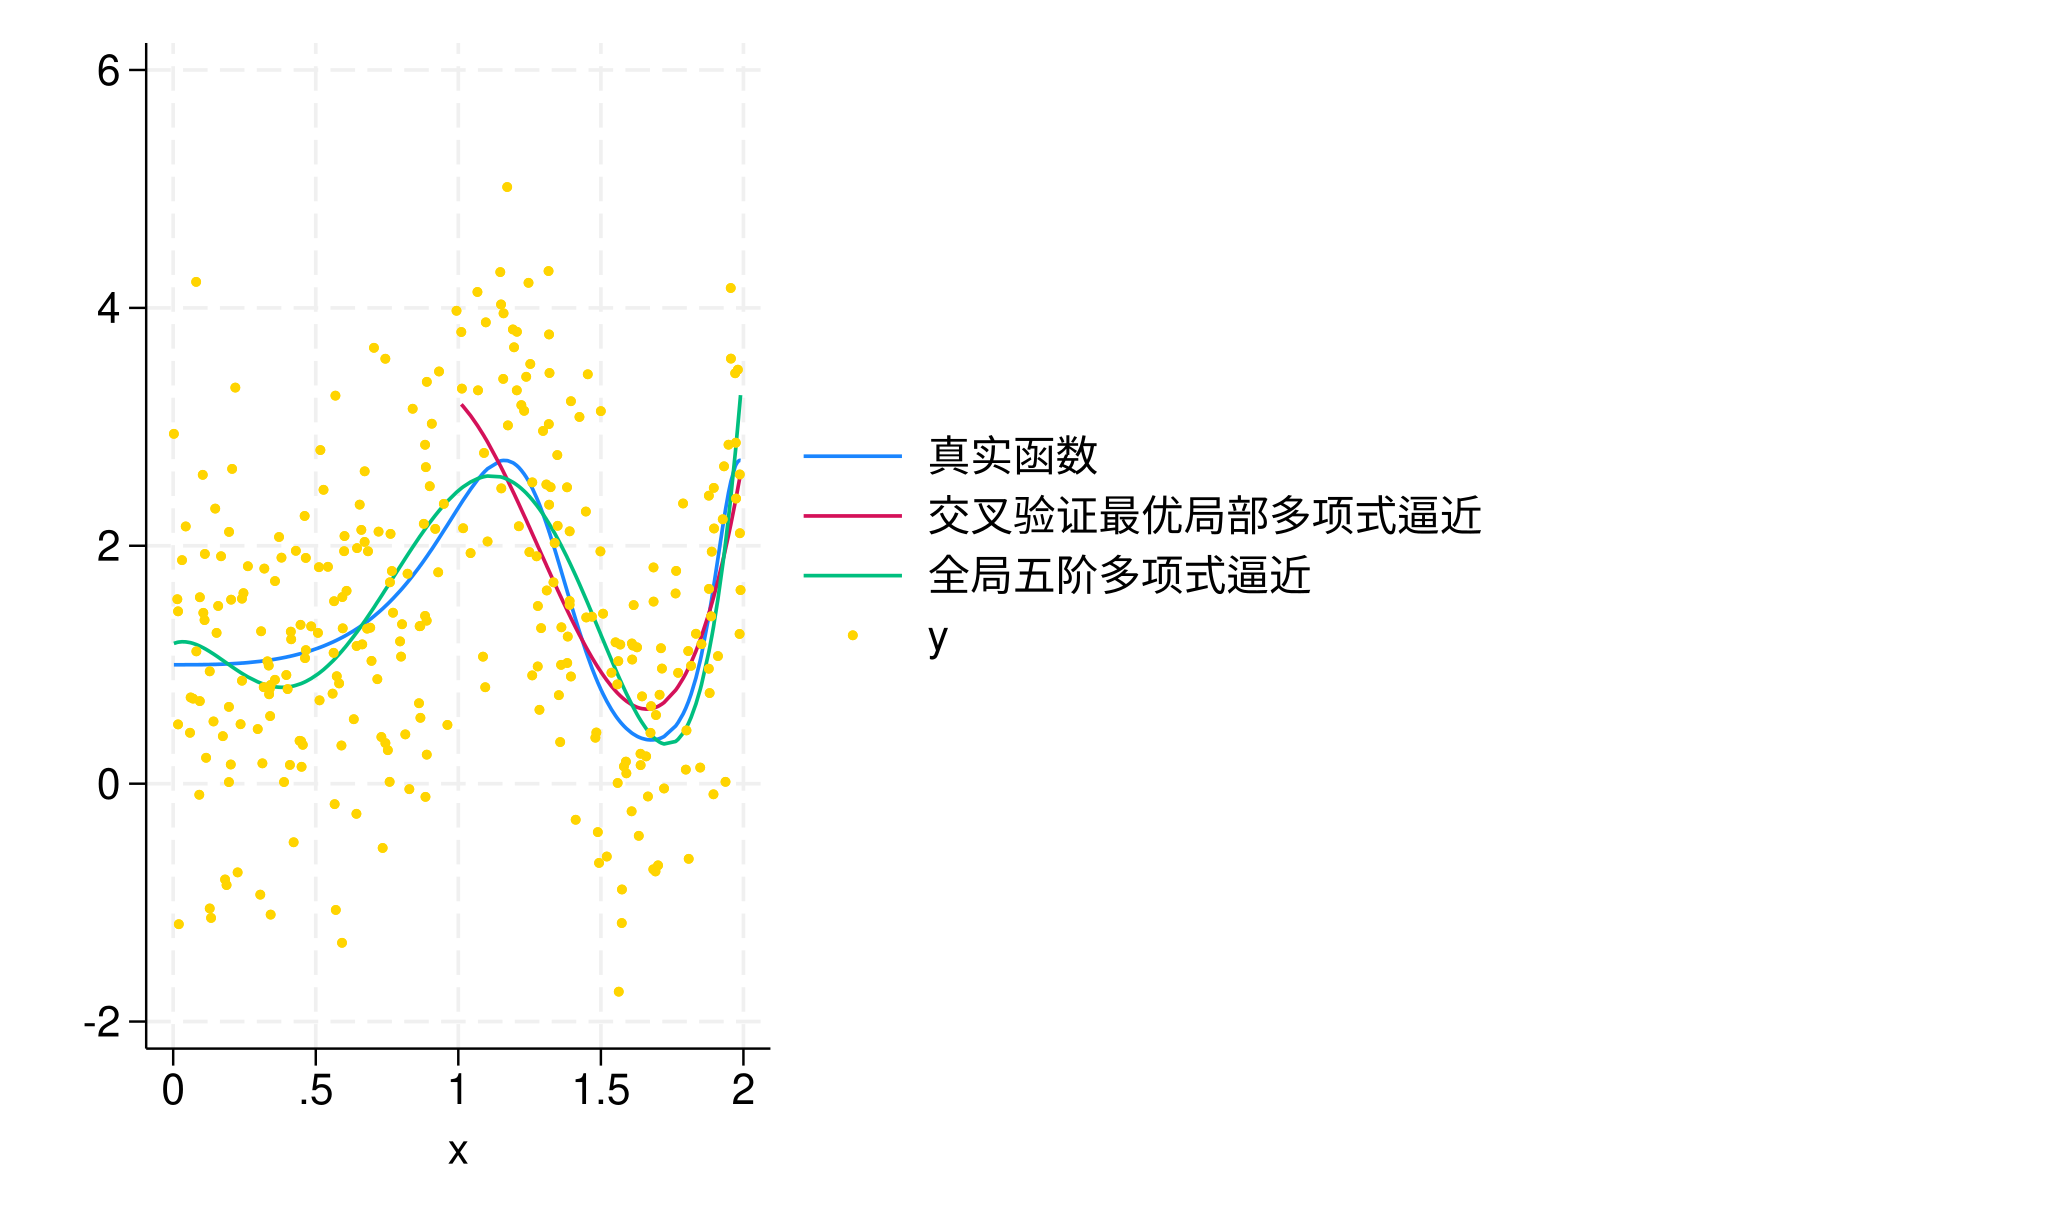

In [13]:
%%stata
twoway (line y_true x) ///
    (line y_local_poly x) ///
    (line y_global_poly x) ///
    (scatter y x, msize(0.5))